<a href="https://colab.research.google.com/github/ldaniel-hm/eml_tabular/blob/main/MonteCarloTodasLasVisitas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Monte Carlo con Políticas epsilon-soft**

_Esto es un ejemplo de uso de Gymnasium e informe sobre un experimento de aprendizaje por refuerzo_

````
Luis D. Hernández.
<ldaniel at um.es>
````

Este notebook describe un experimento de aprendizaje por refuerzo utilizando el algoritmo de Monte Carlo con políticas epsilon-soft. El propósito de este análisis es entrenar un agente en un entorno de gym con el juego "FrozenLake", un entorno estándar en el que el agente debe aprender a moverse a través de un mapa en busca de una meta, evitando caer en agujeros. A continuación, se presenta una descripción de las diferentes partes del código y el proceso utilizado en el experimento.

🎯 **Ojo, el código debe modificarse para ser un auténtico Monte Carlo. Supongo que sabrás darte cuenta.**

## **1. Preparación del Entorno**

La preparación consta de las siguientes partes:
- **Instalación de Dependencias**: Se instalan las librerías necesarias para utilizar el entorno `gymnasium` para la simulación, con el objetivo de crear un ambiente controlado para que el agente pueda interactuar.
- **Importación de Librerías**: Se importan las bibliotecas necesarias como `numpy` para el manejo de matrices y `matplotlib` para la visualización de los resultados.

- **Importación del Entorno "FrozenLake"**:
Se cargan dos versiones del entorno "FrozenLake": una de 4x4 y otra de 8x8. Ambas versiones no son resbaladizas, lo que facilita la comprensión de los resultados, dado que el entorno resbaladizo podría dificultar la comprensión inicial del aprendizaje.

#### 3. **Funciones para Mostrar los Resultados**
   - Se define una función para graficar la proporción de recompensas obtenidas en cada episodio del entrenamiento. Esto ayuda a visualizar el progreso del agente en términos de su desempeño durante el entrenamiento.



##### _________ **Código de la Instalación e Importación**
----

In [1]:
%%capture
#@title Instalamos gym
!pip install 'gym[box2d]==0.20.0'

## Instalación de algunos paquetes.
#!apt-get update
## Para usar gymnasium[box2d]
#!apt install swig
#!pip install gymnasium[box2d]


In [2]:
#@title Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym

# Garantizamos reproducibilidad
import random
random.seed(42)
np.random.seed(42)

In [3]:
#@title Importamos el lago helado
name = 'FrozenLake-v1'
env4 = gym.make(name, is_slippery=False, map_name="4x4", render_mode="ansi") # No resbaladizo para entender mejor los resultados.
env8 = gym.make(name, is_slippery=False, map_name="8x8", render_mode="ansi") # No resbaladizo para entender mejor los resultados.
env4.action_space.seed(42) # Reproducibilidad en la acción aleatoria
env8.action_space.seed(42) # Reproducibilidad en la acción aleatoria

42

## **2. Diseño del Agente**

El diseño del agente consta de dos partes, el algoritmo con el que aprende y las políticas (toma de decisiones) que realiza.

- **Políticas del Agente**
   - **Política epsilon-soft**: Se define una política donde todas las acciones tienen una probabilidad de ser elegida.
   - **Política epsilon-greedy**: basada en la política epsilon-soft. De esta forma el agente tiene una pequeña probabilidad de explorar (tomar una acción aleatoria) y una mayor probabilidad de explotar (tomar la acción que considera mejor). Esto permite equilibrar la exploración y la explotación.
   - **Política greedy**: Es la usada una vez que "ha aprendido".

- **Algoritmo de Iteración de Valor**
  - Se implementa el algoritmo de iteración de valor utilizando Monte Carlo.
  - Se usa una versión "on-policy" de Monte Carlo con políticas epsilon greedy sobre una política epsilon-soft.
  - Se basa en el criterio de todas las visitas.
  - Otro aspecto es que la actualización de los retornos no se realiza en el orden inverso a las visitas.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym

# @title Diseño del Agente Monte Carlo

class FrozenLakeAgent:
    def __init__(
        self,
        env: gym.Env,

        epsilon: float =0.4,

        initial_epsilon: float = 1.0,
        epsilon_decay: float = 0.01,
        final_epsilon: float = 0.01,

        discount_factor: float = 1.0,
        decay=False
    ):
        """Inicializa todo lo necesario para el aprendizaje"""
        self.env = env
        self.epsilon = epsilon
        self.discount_factor = discount_factor
        self.decay = decay
        self.initial_epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon
        
        # Track learning progress
        self.training_error = []

        # Inicializamos la tabla Q y el contador de visitas (N)
        self.Q = np.zeros([env.observation_space.n, env.action_space.n])
        self.n_visits = np.zeros([env.observation_space.n, env.action_space.n])

    def get_action(self, state) -> int:
        """
        Política epsilon-greedy: 
        Con probabilidad epsilon, exploramos tomando una acción aleatoria.
        Con probabilidad (1 - epsilon), explotamos tomando la mejor acción conocida.
        """
        if np.random.random() < self.epsilon:
            return self.env.action_space.sample()
        else:
            return int(np.argmax(self.Q[state, :]))

    def update(
        self,
        episode
    ):
        """
        Auténtico algoritmo Monte Carlo (Every-Visit).
        Actualiza los valores Q recorriendo el episodio hacia atrás para calcular
        el retorno G de manera eficiente.
        """
        G = 0.0
        # episode contiene tuplas de (estado, acción, recompensa)
        for state, action, reward in reversed(episode):
            G = reward + self.discount_factor * G
            self.n_visits[state, action] += 1.0
            
            # Tasa de aprendizaje incremental alpha = 1 / N(s,a)
            alpha = 1.0 / self.n_visits[state, action]
            
            # Actualizamos el valor Q
            self.Q[state, action] += alpha * (G - self.Q[state, action])

    def decay_epsilon(self, t):
        """Aplica el decaimiento de epsilon si está activado."""
        if self.decay:
            self.epsilon = max(self.final_epsilon, self.initial_epsilon / (self.epsilon_decay *t + 1))


def train_agent(env, num_episodes=5000, epsilon=0.4, decay=False, discount_factor=1.0):
    agent = FrozenLakeAgent(
        env=env,
        epsilon=epsilon,
        decay=decay,
        discount_factor=discount_factor,
        initial_epsilon=epsilon,
        epsilon_decay=0.01,
        final_epsilon=0.01
    )
    
    list_stats = []        # Proporción de éxitos acumulada
    episode_lengths = []   # Longitud (f(t) = len(episodio_t))
    stats = 0.0            # Éxitos totales (recompensas obtenidas)
    
    for t in tqdm(range(num_episodes)):
        state, info = env.reset(seed=100 if t==0 else None)
        done = False
        episode = []
        
        # Actualizamos epsilon antes de empezar el episodio
        agent.decay_epsilon(t)
        
        while not done:
            action = agent.get_action(state)
            new_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            episode.append((state, action, reward))
            state = new_state
            
        # Al finalizar el episodio, el agente actualiza sus valores Q (Monte Carlo)
        agent.update(episode)
        
        # Guardamos estadísticas
        # En FrozenLake, la recompensa al final es 1 si llega a la meta, 0 en el resto
        episode_reward = sum([x[2] for x in episode])
        stats += episode_reward
        list_stats.append(stats / (t + 1))
        
        # Guardamos la longitud de este episodio
        episode_lengths.append(len(episode))
        
    return agent.Q, list_stats, episode_lengths

In [5]:
Q, list_stats, episode_lengths = train_agent(env4, num_episodes=5000, epsilon=0.4, decay=False, discount_factor=1.0)


100%|██████████| 5000/5000 [00:01<00:00, 4998.60it/s]


#### **Código de las políticas y algoritmo MC**
----------------

In [6]:
# @title Políticas del agente

# actions
LEFT, DOWN, RIGHT, UP = 0,1,2,3

# Política epsilon-soft. Se usa para el entrenamiento
def random_epsilon_greedy_policy(Q, epsilon, state, nA):
    pi_A = np.ones(nA, dtype=float) * epsilon / nA
    best_action = np.argmax(Q[state])
    pi_A[best_action] += (1.0 - epsilon)
    return pi_A

# Política epsilon-greedy a partir de una epsilon-soft
def epsilon_greedy_policy(Q, epsilon, state, nA):
    pi_A = random_epsilon_greedy_policy(Q, epsilon, state, nA)
    return np.random.choice(np.arange(nA), p=pi_A)

# Política Greedy a partir de los valones Q. Se usa para mostrar la solución.
def pi_star_from_Q(env, Q):
    done = False
    pi_star = np.zeros([env.observation_space.n, env.action_space.n])
    state, info = env.reset() # start in top-left, = 0
    actions = ""
    while not done:
        action = np.argmax(Q[state, :])
        actions += f"{action}, "
        pi_star[state,action] = action
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
    return pi_star, actions

In [7]:
#@title Algoritmo de Iteración de Valor versión MC con Políticas epsilon-soft

def on_policy_all_visit(env, num_episodes=5000, epsilon=0.4, decay=False, discount_factor=1):
    # Matriz de valores  Q
    nA = env.action_space.n
    Q = np.zeros([env.observation_space.n, nA])

    # Número de visitas. Vamoa a realizar la versión incremental.
    n_visits = np.zeros([env.observation_space.n, env.action_space.n])

    success_history = [] # NEW
    length_history = [] # NEW

    # Para mostrar la evolución en el terminal y algún dato que mostrar
    stats = 0.0
    list_stats = [stats]
    step_display = num_episodes / 10

    first_success_found = False 

    for t in tqdm(range(num_episodes)):
        state, info = env.reset(seed=100)
        done = False
        episode = []
        result_sum = 0.0  # Retorno
        factor = 1
        while not done:
          if decay:
            epsilon = min(1.0, 1000.0/(t+1))
          action = epsilon_greedy_policy(Q, epsilon, state, nA)
          new_state, reward, terminated, truncated, info = env.step(action)
          done = terminated or truncated
          episode.append((state, action,reward))# episode.append((state, action))
          #result_sum += factor * reward
          #factor *= discount_factor
          state = new_state

        length_history.append(len(episode)) # NEW
       # ---- Evaluación hacia atrás usando máximo ----
        G = 0.0

        # Detectamos si este es el primer éxito
        if not first_success_found:
            temp_G = 0.0
            for (_, _, reward) in reversed(episode):
                temp_G = reward + discount_factor * temp_G

            if temp_G > 0:
                print("\n==============================")
                print(f"Primer estado terminal alcanzado en episodio {t}")
                print("Política ANTES de actualizar:\n",
                      np.argmax(Q, axis=1))
                print("==============================\n")
                first_success_found = True

        for state, action, reward in reversed(episode):
            G = reward + discount_factor * G
            n_visits[state, action] += 1.0
            alpha = 1.0 / n_visits[state, action]
            # Evaluación por máximo (tipo control)
            Q[state, action] += alpha * (G - Q[state, action])


      # Imprimir política después de actualizar
        if first_success_found and temp_G > 0:
            print("\n==============================")
            print("Política DESPUÉS de actualizar:\n",
                  np.argmax(Q, axis=1))
            print("==============================\n")
            # Para no volver a imprimir
            temp_G = -1

        success_history.append(1 if G > 0 else 0) # NEW
        
        stats += G

    # Esto es un disparate ¿por qué?
    #   for (state, action) in episode:
    #       n_visits[state, action] += 1.0
    #       alpha = 1.0 / n_visits[state, action]
    #       Q[state, action] += alpha * (result_sum - Q[state, action])
        
        

        # Guardamos datos sobre la evolución. Promedio de recompensas
        #stats += result_sum
        list_stats.append(stats/(t+1))

        # Para mostrar la evolución.  Comentar si no se quiere mostrar
        if t % step_display == 0 and t != 0:
            print(f"success: {stats/t}, epsilon: {epsilon}")
    # success_curve = np.cumsum(success_history) / np.arange(1, num_episodes + 1)# NEW
    return Q, list_stats, length_history


## **3. Experimentación**

   - En esta sección, el algoritmo de Monte Carlo con la política epsilon (decaimiento) se ejecuta tanto para el entorno de 4x4 como al de 8x8 de FrozenLake sin resbalar.
   
   - En ambos casos se realiza un entrenamiento con un número determinado de episodios (5000 en concreto)

   - Además en el escenario 8x8 el  epsilon tiene decaimiento de acuerdo a la expresión: $\epsilon = min(1.0, 1000.0/(t+1))$

   - Durante el entrenamiento hay una visualización de la proporción de recompensas obtenidas a lo largo del entrenamiento.

   - Junto a dicho volcado se muestra gráficamente la proporcion de recompensas obtendias.

   - También se hace un volcado de los valores Q de cada estado, donde se muestra cómo el agente valora diferentes acciones en distintos estados del entorno, lo que puede interpretarse como su conocimiento sobre las mejores estrategias para alcanzar la meta sin caer en los agujeros.

   - Además, se muestra la política óptima derivada de los valores Q. Esta política es la que el agente seguiría si tuviera que elegir siempre la acción que maximiza su recompensa esperada.

   

### **3.1 Repressentaciones Gráficas**

Para comprobar el aprendizaje se mostrará la función $f(t)=\frac{\sum_{i=1}^t R_i}{t}$ para $t=1,2,\ldots, NumeroEpisodios$. La justificación es la siguiente. Como sabemmos que el retorno en el estados inicial 1 (pues no hay descuento) o 9, si se divide por el número de episodios ejecutados se calcular el porcentaje de recompensas positivas obtenidas. Dicho de otra forma, nos dirá el porcentaje de veces que el agente ha llegado al estado terminal.

*TODO:* Contruir una gráfica que muestre la longitud de los episodios en cada estado junto con la curva de tendencia.

In [8]:
# @title Funciones para mostrar los resultados

def plot(list_stats):
  # Creamos una lista de índices para el eje x
  indices = list(range(len(list_stats)))

  # Creamos el gráfico
  plt.figure(figsize=(6, 3))
  plt.plot(indices, list_stats)

  # Añadimos título y etiquetas
  plt.title('Proporción de recompensas')
  plt.xlabel('Episodio')
  plt.ylabel('Proporción')

  # hacemos el eje x de la gráfica logarítmico para ver mejor la evolución al principio del entrenamiento
  plt.xscale("log")
  
  # Mostramos el gráfico
  plt.grid(True)
  plt.show()


# Define la función para mostrar el tamaño de los episodios
# Pon aquí tu código.

### **3.2 Experimentación en el escenario 4x4**



   - Se realizan 5000 epsisodios y se actualizan los valores Q (valor de acción) basándose en las recompensas obtenidas durante cada episodio completo (e.d. aplicamos Monte Carlo) Se apica una política $\epsilon$ greedy sobre una política $\epsilon$ soft con un valor $\epsilon$ constante




In [9]:
# @title Aprendizaje
Q, list_stats, length_history = on_policy_all_visit(env4, num_episodes=50000, epsilon=0.4, discount_factor=1)

  1%|▏         | 673/50000 [00:00<00:26, 1884.97it/s]


Primer estado terminal alcanzado en episodio 229
Política ANTES de actualizar:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


Política DESPUÉS de actualizar:
 [1 0 0 0 1 0 0 0 2 2 1 0 0 0 1 0]



 11%|█         | 5564/50000 [00:02<00:14, 2965.05it/s]

success: 0.4864, epsilon: 0.4


 21%|██        | 10493/50000 [00:03<00:12, 3094.30it/s]

...

 81%|████████  | 40473/50000 [00:13<00:02, 3180.96it/s]

success: 0.5355, epsilon: 0.4


 91%|█████████ | 45473/50000 [00:15<00:01, 3111.65it/s]

success: 0.5370444444444444, epsilon: 0.4


100%|██████████| 50000/50000 [00:16<00:00, 2987.28it/s]


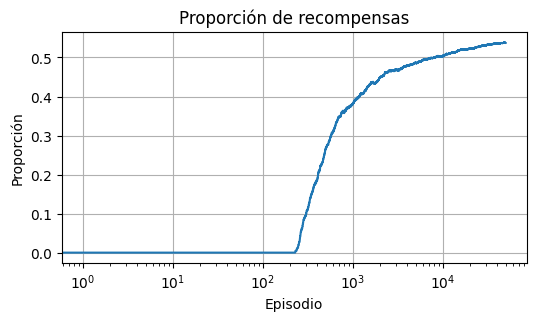

Máxima proporcion: 0.537


In [10]:
#@title Proporción de aciertos por número de episodios

plot(list_stats)
print(f"Máxima proporcion: {list_stats[-1]}")

#### Mostramos los valores Q para cada estado. Cada estado tienen 4 valores, que se corresponden con las 4 acciones que se pueden en cada estado.

In [11]:
# @title Tabla de valores Q
LEFT, DOWN, RIGHT, UP = 0,1,2,3
print("Valores Q para cada estado:\n", Q)


Valores Q para cada estado:
 [[0.42944195 0.53980169 0.4978355  0.52572044]
 [0.41146712 0.         0.58803502 0.49947862]
 [0.48766816 0.60913103 0.46467991 0.59344262]
 [0.54817708 0.         0.36555891 0.43333333]
 [0.48651407 0.6202041  0.         0.53682814]
 [0.         0.         0.         0.        ]
 [0.         0.79457148 0.         0.5265252 ]
 [0.         0.         0.         0.        ]
 [0.59506849 0.         0.71533625 0.55036995]
 [0.60574602 0.82853479 0.79440187 0.        ]
 [0.70097508 0.96062184 0.         0.5810956 ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.83482885 0.9601227  0.73418972]
 [0.83557312 0.95436767 1.         0.80718532]
 [0.         0.         0.         0.        ]]


- También se muestra la política óptima (greedy) obtenida a partir del aprendizaje anterior.

- Cada estado tienen 4 valores, pero todos son 0 menos 1. Es decir, en cada estado se aplica de manera determinística una única acción.

*TODO:* Mostrar de forma gráfica el escenario.

In [12]:
# @title Política final
LEFT, DOWN, RIGHT, UP = 0,1,2,3
pi, actions = pi_star_from_Q(env4, Q)

print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Para el siguiente grid\n", env4.render())
print()

Política óptima obtenida
 [[0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 0.]] 
 Acciones 1, 1, 2, 1, 2, 2,  
 Para el siguiente grid
   (Right)
SFFF
FHFH
FFFH
HFFG




In [13]:
def plot_episode_lengths(length_history):
    # Nos quedamos con los 100 primeros episodios para mostrar la evolución de la longitud de los episodios
    #length_history = length_history[:100]
    episodes = np.arange(len(length_history))

    plt.figure(figsize=(6,3))
    plt.plot(episodes, length_history, alpha=0.4, label="Longitud episodio")

    # curva de tendencia (media móvil)
    window = 100
    moving_avg = np.convolve(length_history,
                             np.ones(window)/window,
                             mode='valid')

    plt.plot(np.arange(len(moving_avg)), moving_avg,
             linewidth=2, label="Media móvil")

    plt.xscale("log")
    plt.xlabel("Episodio")
    plt.ylabel("Longitud")
    plt.title("Longitud de los episodios")
    plt.grid(True)
    plt.legend()
    plt.show()

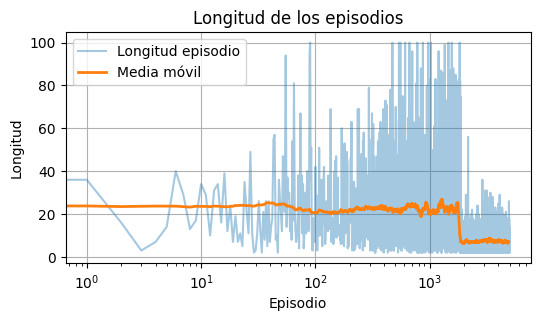

Longitud media de los episodios: 12.9332
Longitud máxima de los episodios: 100
Longitud mínima de los episodios: 2
Longitud total de los episodios: 64666
Longitud total de los episodios: 5000


In [14]:
plot_episode_lengths(episode_lengths)
# Mostramos estadísticos del array de longitud de episodios
print(f"Longitud media de los episodios: {np.mean(episode_lengths)}")
print(f"Longitud máxima de los episodios: {np.max(episode_lengths)}")
print(f"Longitud mínima de los episodios: {np.min(episode_lengths)}")
print(f"Longitud total de los episodios: {np.sum(episode_lengths)}")
print(f"Longitud total de los episodios: {len(episode_lengths)}")

La gráfica de la longitud de los episodios es un buen indicador de aprendizaje por las siguientes razones:

- Fase de exploración inicial: Al principio, el agente actúa de manera aleatoria, por lo que suele caer rápidamente en los agujeros. Esto se traduce en episodios muy cortos. Nótese que la longitud máxima de los episodios es 100, por lo que si el agente no cae en un agujero, el episodio se trunca a los 100 pasos (por implementación de Gymnasium).
  
- Fase de aprendizaje: En el episodio 400 llega al estado terminal por primera vez. A partir de este instante, el valor de los estados empieza a cambiar y el agente comienza a aprender a evitar los agujeros y llegar de forma más rápida a la meta. Esto se refleja en una disminución de la longitud de episodios.

Por tanto, ver que la longitud sube y luego converge hacia el camino mínimo posible es un indicador claro de que el agente ha comprendido la dinámica del entorno.

### **3.3 Experimentación en el escenario 8x8**

  - Se realizan 5000 epsisodios y se actualizan los valores Q (valor de acción) basándose en las recompensas obtenidas durante cada episodio completo (e.d. aplicamos Monte Carlo) Se apica una política $\epsilon$ greedy sobre una política $\epsilon$ soft con un valor $\epsilon$ decreciente



In [15]:
# @title Aprendizaje
Q, list_stats, length_history = on_policy_all_visit(env8, num_episodes=50000, epsilon=0.4, decay=True, discount_factor=1)

  1%|          | 506/50000 [00:00<01:07, 730.86it/s]


Primer estado terminal alcanzado en episodio 415
Política ANTES de actualizar:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


Política DESPUÉS de actualizar:
 [3 0 0 0 0 0 0 0 1 1 2 2 2 1 0 0 2 1 3 0 1 0 0 0 2 3 0 0 1 0 0 0 3 0 0 0 2
 2 2 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]



 10%|█         | 5060/50000 [00:09<01:47, 417.35it/s]

success: 0.4194, epsilon: 0.19996000799840033


 20%|██        | 10078/50000 [00:20<01:13, 545.00it/s]

...

 80%|████████  | 40220/50000 [00:57<00:06, 1469.23it/s]

success: 0.847675, epsilon: 0.02499937501562461


 91%|█████████ | 45311/50000 [01:00<00:03, 1515.29it/s]

success: 0.8625333333333334, epsilon: 0.02222172840603542


100%|██████████| 50000/50000 [01:03<00:00, 787.31it/s] 


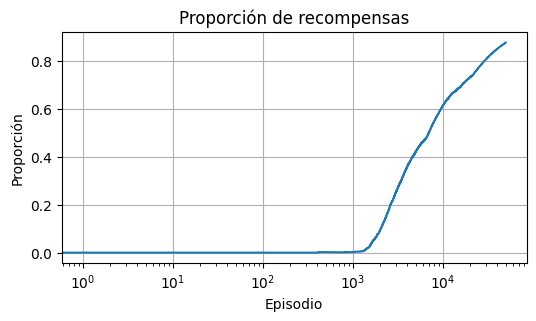

Máxima proporcion: 0.87466


In [16]:
#@title Proporción de aciertos por número de episodios

plot(list_stats)
print(f"Máxima proporcion: {list_stats[-1]}")

#### Mostramos los valores Q para cada estado. Cada estado tienen 4 valores, que se corresponden con las 4 acciones que se pueden en cada estado.

In [17]:
# @title Tabla de valores Q
LEFT, DOWN, RIGHT, UP = 0,1,2,3
print("Valores Q para cada estado:\n", Q)

Valores Q para cada estado:
 [[0.56448378 0.87577173 0.65699281 0.66999913]
 [0.4261352  0.54484305 0.76792193 0.64775903]
 [0.21615472 0.24118316 0.81050285 0.25429553]
 [0.33880597 0.32153392 0.84131227 0.34334764]
 [0.42662116 0.86098494 0.42481752 0.40688576]
 [0.19708029 0.70310296 0.20350877 0.18796992]
 [0.2        0.66575342 0.1875     0.21296296]
 [0.21860465 0.75791624 0.29824561 0.26712329]
 [0.36759164 0.35578187 0.76859746 0.33125205]
 [0.39477557 0.43573866 0.92812259 0.43914169]
 [0.41737649 0.45759866 0.92812087 0.49237288]
 [0.60432432 0.         0.94804967 0.61629153]
 [0.66905188 0.64080944 0.94496197 0.66435386]
 [0.6953271  0.68732126 0.94943247 0.70856102]
 [0.73258197 0.73577982 0.9515062  0.70850202]
 [0.7495183  0.95251323 0.72258065 0.74925373]
 [0.29348384 0.29507389 0.29661836 0.44218258]
 [0.43131868 0.29479769 0.41323106 0.34027778]
 [0.12873563 0.18219462 0.         0.59742418]
 [0.         0.         0.         0.        ]
 [0.         0.2        0.28859

- También se muestra la política óptima (greedy) obtenida a partir del aprendizaje anterior.

- Cada estado tienen 4 valores, pero todos son 0 menos 1. Es decir, en cada estado se aplica de manera determinística una única acción.

*TODO:* Mostrar de forma gráfica el escenario.

In [18]:
# @title Política final
LEFT, DOWN, RIGHT, UP = 0,1,2,3
pi, actions = pi_star_from_Q(env8, Q)

print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Para el siguiente grid\n", env8.render())
print()


Política óptima obtenida
 [[0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] 
 Acciones 1,

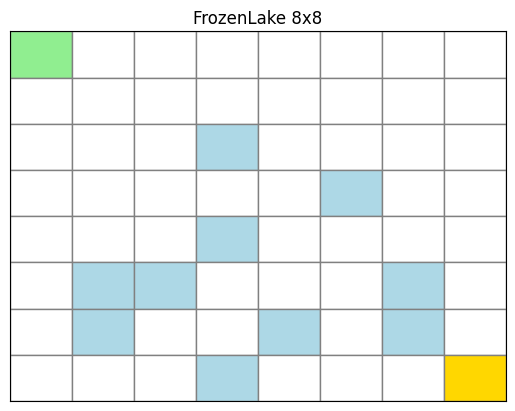

In [19]:
import numpy as np
import matplotlib.pyplot as plt

grid = [
    list("SFFFFFFF"),
    list("FFFFFFFF"),
    list("FFFHFFFF"),
    list("FFFFFHFF"),
    list("FFFHFFFF"),
    list("FHHFFFHF"),
    list("FHFFHFHF"),
    list("FFFHFFFG")
]

n = 8
fig, ax = plt.subplots()

for i in range(n):
    for j in range(n):
        cell = grid[i][j]
        
        color = {
            'S': 'lightgreen',
            'F': 'white',
            'H': 'lightblue',
            'G': 'gold'
        }[cell]
        
        rect = plt.Rectangle((j, n-i-1), 1, 1, facecolor=color, edgecolor='gray')
        ax.add_patch(rect)

ax.set_xlim(0, n)
ax.set_ylim(0, n)
ax.set_xticks([])
ax.set_yticks([])
plt.title("FrozenLake 8x8")
plt.show()

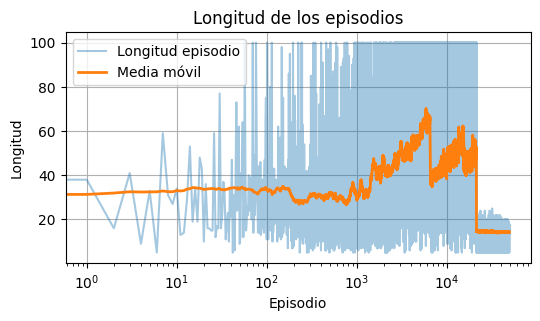

In [20]:
plot_episode_lengths(length_history)

## **4. Análisis y Estudios Futuros**

### **4.1 Análisis de Resultados**

- En los dos entornos (4x4 y 8x8), el agente comienza con un conocimiento muy limitado, pero gradualmente mejora su desempeño a medida que avanza en los episodios. Este comportamiento se puede observar en el gráfico de la proporción de recompensas, que aumenta con el tiempo.
- En el entorno 4x4, la máxima proporción de éxito alcanzada fue 0.522, mientras que en el entorno 8x8, la máxima alcanzada fue 0.914. Esto refleja que el agente aprendió a optimizar su estrategia en un entorno más complejo.
- La política óptima obtenida muestra las acciones recomendadas por el agente en cada estado del entorno. En el entorno 8x8, la política es más compleja debido a la mayor cantidad de estados y la dificultad del entorno.

### **4.2 Propuestas para Estudios Futuros**

1. **Evaluar con Otros Entornos**: Sería interesante aplicar este algoritmo a otros entornos más complejos de `gym`, como "Taxi-v3" o "MountainCar", para analizar cómo se comporta el agente en situaciones con dinámicas más complicadas.
   
2. **Optimización del Decaimiento de Epsilon**: Aunque se utilizó un decaimiento de epsilon en el segundo experimento, se podría investigar la efectividad de diferentes tasas de decaimiento o incluso explorar algoritmos como `Q-learning` para comparar su desempeño. Graficamente se trataría de mostrar la curva de la tasa de aciertos para distintas funciones de decaimientos

3. **Análisis del Impacto de los descuentos en las Recompensas**: El estudio se ha hecho para $\gamma = 1$; pero no se ha probado qué pasa cuando  $0 \leq \gamma < 1$. Se trataría de estudiar la curva para distintos valores de $\gamma$

4. **Nuevas gráficas**: Aquí solo se ha usado la proporción de aciertos, pero sería interesante qué relación entre dicha tasa y las tamaños de los episodios.

4. **Ampliación del Algoritmo**: Explorar otros enfoques de Monte Carlo o incluso combinar Monte Carlo con otros algoritmos de aprendizaje por refuerzo, como el Deep Q-Network (DQN), podría mejorar aún más los resultados en entornos más complejos.
